In [1]:
import re
import gc

from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import warnings
warnings.filterwarnings(action="ignore")

from pymorphy3 import MorphAnalyzer
from stop_words import get_stop_words

from IPython.display import display

import matplotlib as mpl
mpl.rcParams["font.style"] = "oblique"
mpl.rcParams["axes.grid"] = True

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize, Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics.cluster import pair_confusion_matrix
from scipy.stats import spearmanr

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("./data.csv")
df.head()

,row_id,text,original_label,story_id,message_type,hierarchy_l1,hierarchy_l2,hierarchy_l3,hierarchy_l4,hierarchy_l5,hierarchy,hF1_path,hF1_ancestors,story_size,review_status,review_reason
0,1,"❗️Визит президента Сербии в силе, он летит в М...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
1,2,"Самолет президента Сербии Вучича, направлявший...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
2,3,Власти Литвы запретили перелет в воздушном про...,9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
3,4,"Вучич, прервавший поездку в США из-за недомога...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story;exact_dupli...
4,5,"Вучич, прервавший поездку в США из-за недомога...",vuchich_ill,vucic_health_incident,fact,politics,europe,serbia,leadership_health,NaN,politics/europe/serbia/leadership_health,root/politics/europe/serbia/leadership_health/...,root|root/politics|root/politics/europe|root/p...,4,review,check_boundary_with_adjacent_story;exact_dupli...


In [3]:
df.shape

(863, 16)

In [4]:
MORPH = MorphAnalyzer()
RU_STOPWORDS = set(get_stop_words("russian"))

In [5]:
#del model_embeddings2

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [6]:
model_statistics = make_pipeline(
    TfidfVectorizer(
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2)
    ),
    TruncatedSVD(
        n_components=300,
        random_state=42
    ),
    Normalizer(copy=False)
)

In [7]:
# todo: run both
#model_embeddings1 = SentenceTransformer(
#    "jinaai/jina-embeddings-v3", trust_remote_code=True, device="cuda"
#)
#model_embeddings2 = SentenceTransformer(
#    "jinaai/jina-embeddings-v5-text-small", trust_remote_code=True, device="cuda"
#)

# gpu issue (FP 16 mode)
#model_embeddings1.half()
#model_embeddings2.half()

In [8]:
def make_noise_singletons(y_pred, noise_label=-1):
    y_pred = np.asarray(y_pred).copy()
    noise_mask = y_pred == noise_label

    if not np.any(noise_mask):
        return y_pred

    non_noise = y_pred[~noise_mask]
    next_label = int(np.max(non_noise)) + 1 if non_noise.size else 0

    for offset, idx in enumerate(np.where(noise_mask)[0]):
        y_pred[idx] = next_label + offset

    return y_pred


def fbeta_score_from_precision_recall(precision, recall, beta=1.0):
    beta2 = beta ** 2
    denominator = beta2 * precision + recall

    if denominator == 0:
        return 0

    return (1 + beta2) * precision * recall / denominator


def pairwise_metrics(y_true, y_pred):
    tn, fp, fn, tp = pair_confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = fbeta_score_from_precision_recall(precision, recall, beta=1.0)
    f05 = fbeta_score_from_precision_recall(precision, recall, beta=0.5)

    return precision, recall, f1, f05


In [9]:
def compute_true_paths(df, col="hF1_ancestors", sep="|"):
    return [
        [node for node in str(value).split(sep) if node]
        for value in df[col]
    ]


def strip_root(path, root="root"):
    return [node for node in path if node != root]


def gold_hierarchy_nodes(true_paths, root="root", min_size=2):
    n = len(true_paths)
    groups = defaultdict(list)

    for i, path in enumerate(true_paths):
        for node in strip_root(path, root):
            groups[node].append(i)

    return [
        frozenset(indices)
        for indices in groups.values()
        if min_size <= len(set(indices)) < n
    ]


def weighted_best_overlap_f1(source_nodes, target_nodes):
    if not source_nodes or not target_nodes:
        return np.nan

    total_weight = 0
    weighted_sum = 0.0

    for source in source_nodes:
        source_size = len(source)
        best_f1 = 0.0

        for target in target_nodes:
            intersection = len(source & target)
            if intersection == 0:
                continue

            best_f1 = max(
                best_f1,
                2 * intersection / (len(source) + len(target))
            )

        weighted_sum += source_size * best_f1
        total_weight += source_size

    return weighted_sum / total_weight if total_weight else np.nan


def condensed_tree_to_pandas(condensed_tree):
    if condensed_tree is None:
        return None

    if hasattr(condensed_tree, "to_pandas"):
        return condensed_tree.to_pandas()

    if isinstance(condensed_tree, pd.DataFrame):
        return condensed_tree.copy()

    raise TypeError("condensed_tree must be an HDBSCAN CondensedTree or a pandas DataFrame")


def build_condensed_tree_info(condensed_tree, n_samples):
    tree_df = condensed_tree_to_pandas(condensed_tree)

    if tree_df is None or tree_df.empty:
        return None

    children = defaultdict(list)
    parent_of = {}
    child_size = {}
    lambda_val = {}

    for row in tree_df.itertuples(index=False):
        parent = int(row.parent)
        child = int(row.child)
        children[parent].append(child)
        parent_of[child] = parent
        child_size[child] = int(row.child_size)
        lambda_val[child] = float(row.lambda_val)

    parent_nodes = set(children.keys())
    child_nodes = set(parent_of.keys())
    roots = list(parent_nodes - child_nodes)

    if roots:
        root = roots[0]
    else:
        # Fallback for unexpected formats: choose the parent with the largest covered subtree.
        root = max(parent_nodes, key=lambda node: len(children[node]))

    all_nodes = parent_nodes | child_nodes | set(range(n_samples))

    @lru_cache(maxsize=None)
    def collect_leaves(node):
        if node < n_samples:
            return frozenset([node])

        leaves = frozenset()
        for child in children.get(node, []):
            leaves = leaves | collect_leaves(child)

        return leaves

    leaf_sets = {
        node: collect_leaves(node)
        for node in all_nodes
        if node >= n_samples or node in parent_of
    }

    sample_paths = {}
    for sample_idx in range(n_samples):
        path = []
        node = sample_idx
        seen = set()

        while node in parent_of and node not in seen:
            seen.add(node)
            parent = parent_of[node]
            if parent >= n_samples:
                path.append(parent)
            node = parent

        # Root-to-leaf cluster path. Sample node itself is intentionally excluded.
        sample_paths[sample_idx] = list(reversed(path))

    return {
        "tree_df": tree_df,
        "children": children,
        "parent_of": parent_of,
        "child_size": child_size,
        "lambda_val": lambda_val,
        "root": root,
        "leaf_sets": leaf_sets,
        "sample_paths": sample_paths,
    }


def condensed_tree_to_hierarchy_nodes(condensed_tree, n_samples, min_size=2, include_root=False):
    info = build_condensed_tree_info(condensed_tree, n_samples)

    if info is None:
        return []

    root = info["root"]
    nodes = []
    seen = set()

    for node, leaves in info["leaf_sets"].items():
        if node < n_samples:
            continue

        size = len(leaves)
        if size < min_size:
            continue
        if node == root and not include_root:
            continue
        if size >= n_samples and not include_root:
            continue
        if leaves in seen:
            continue

        seen.add(leaves)
        nodes.append(leaves)

    return nodes


def hierarchical_cluster_fscore(condensed_tree, true_paths, root="root", min_size=2):
    n = len(true_paths)
    gold_nodes = gold_hierarchy_nodes(true_paths, root=root, min_size=min_size)
    pred_nodes = condensed_tree_to_hierarchy_nodes(condensed_tree, n, min_size=min_size)

    h_precision = weighted_best_overlap_f1(pred_nodes, gold_nodes)
    h_recall = weighted_best_overlap_f1(gold_nodes, pred_nodes)

    if np.isfinite(h_precision) and np.isfinite(h_recall) and h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = np.nan

    return h_precision, h_recall, h_f1


def common_prefix_len(path_a, path_b, root="root"):
    length = 0

    for node_a, node_b in zip(path_a, path_b):
        if node_a != node_b:
            break
        if node_a != root:
            length += 1

    return length


@lru_cache(maxsize=8)
def _gold_hierarchy_pairwise_arrays_cached(paths, root="root"):
    n = len(paths)
    n_pairs = n * (n - 1) // 2

    lca_similarity = np.empty(n_pairs, dtype=float)
    tree_distance = np.empty(n_pairs, dtype=float)
    path_depths = [len(strip_root(path, root=root)) for path in paths]

    k = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            lca_depth = common_prefix_len(paths[i], paths[j], root=root)

            lca_similarity[k] = lca_depth
            tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca_depth
            k += 1

    return lca_similarity, tree_distance


def gold_hierarchy_pairwise_arrays(true_paths, root="root"):
    return _gold_hierarchy_pairwise_arrays_cached(
        tuple(tuple(path) for path in true_paths),
        root=root,
    )


def condensed_tree_pairwise_arrays(condensed_tree, n_samples):
    info = build_condensed_tree_info(condensed_tree, n_samples)

    if info is None:
        return None, None

    sample_paths = info["sample_paths"]
    root = info["root"]
    n_pairs = n_samples * (n_samples - 1) // 2

    pred_lca_similarity = np.empty(n_pairs, dtype=float)
    pred_tree_distance = np.empty(n_pairs, dtype=float)

    def path_depth(path):
        return sum(node != root for node in path)

    def lca_depth(path_a, path_b):
        depth = 0
        for node_a, node_b in zip(path_a, path_b):
            if node_a != node_b:
                break
            if node_a != root:
                depth += 1
        return depth

    path_depths = [path_depth(sample_paths[i]) for i in range(n_samples)]

    k = 0
    for i in range(n_samples - 1):
        for j in range(i + 1, n_samples):
            lca = lca_depth(sample_paths[i], sample_paths[j])
            pred_lca_similarity[k] = lca
            pred_tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca
            k += 1

    return pred_lca_similarity, pred_tree_distance


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan

    x = x[mask]
    y = y[mask]

    if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
        return np.nan

    return spearmanr(x, y).correlation


def hierarchical_tree_metrics(condensed_tree, true_paths, root="root"):
    if condensed_tree is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    n = len(true_paths)
    gold_lca, gold_distance = gold_hierarchy_pairwise_arrays(true_paths, root=root)
    pred_lca, pred_distance = condensed_tree_pairwise_arrays(condensed_tree, n)

    if pred_lca is None or pred_distance is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    return {
        "lca_similarity_spearman": safe_spearman(gold_lca, pred_lca),
        "tree_distance_spearman": safe_spearman(gold_distance, pred_distance),
    }


def condensed_dendrogram_purity(condensed_tree, y_true):
    if condensed_tree is None:
        return np.nan

    y_true = np.asarray(y_true)
    n = len(y_true)
    info = build_condensed_tree_info(condensed_tree, n)

    if info is None:
        return np.nan

    root = info["root"]
    sample_paths = info["sample_paths"]
    leaf_sets = info["leaf_sets"]

    node_counts = {}
    for node, leaves in leaf_sets.items():
        if node >= n and leaves:
            node_counts[node] = Counter(y_true[list(leaves)])

    def lca_node(path_a, path_b):
        lca = root
        for node_a, node_b in zip(path_a, path_b):
            if node_a != node_b:
                break
            lca = node_a
        return lca

    purity_sum = 0.0
    pair_count = 0

    for i in range(n - 1):
        label = y_true[i]
        for j in range(i + 1, n):
            if y_true[j] != label:
                continue

            node = lca_node(sample_paths[i], sample_paths[j])
            leaves = leaf_sets.get(node, frozenset(range(n)))
            size = len(leaves)

            if size == 0:
                continue

            counts = node_counts.get(node, Counter(y_true[list(leaves)]))
            purity_sum += counts[label] / size
            pair_count += 1

    return purity_sum / pair_count if pair_count else np.nan


In [10]:
def tfidf_preprocessing(text):
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    result = []

    for token in text.split():
        if len(token) < 2: continue
        lemma = MORPH.parse(token)[0].normal_form
        if lemma in RU_STOPWORDS: continue

        result.append(lemma)

    return " ".join(result)

In [11]:
def clustering_metrics(X, y_true, y_pred, true_paths=None, condensed_tree=None):
    y_pred_external = make_noise_singletons(y_pred)
    precision, recall, f1, f05 = pairwise_metrics(y_true, y_pred_external)
    ari = adjusted_rand_score(y_true, y_pred_external)

    if true_paths is not None and condensed_tree is not None:
        h_precision, h_recall, h_f1 = hierarchical_cluster_fscore(
            condensed_tree=condensed_tree,
            true_paths=true_paths,
        )
        tree_metrics = hierarchical_tree_metrics(condensed_tree, true_paths)
        purity = condensed_dendrogram_purity(condensed_tree, y_true)
    else:
        h_precision, h_recall, h_f1 = np.nan, np.nan, np.nan
        tree_metrics = {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }
        purity = np.nan

    mask = y_pred != -1
    internal = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    # Noise handling intentionally stays as before: internal metrics are computed on clustered points only.
    if len(set(y_pred[mask])) >= 2:
        internal["silhouette"] = silhouette_score(X[mask], y_pred[mask])
        internal["calinski_harabasz"] = calinski_harabasz_score(X[mask], y_pred[mask])
        internal["davies_bouldin"] = davies_bouldin_score(X[mask], y_pred[mask])

    return {
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "f0.5-score": f05,
        "h_precision": h_precision,
        "h_recall": h_recall,
        "h_f1-score": h_f1,
        "lca_similarity_spearman": tree_metrics["lca_similarity_spearman"],
        "tree_distance_spearman": tree_metrics["tree_distance_spearman"],
        "dendrogram_purity": purity,
        "ari": ari,
        **internal
    }


In [12]:
def twonn_dimension(X, metric="euclidean", eps=1e-12):
    X = np.asarray(X)

    if len(X) < 3:
        return np.nan

    nn = NearestNeighbors(n_neighbors=3, metric=metric)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    r1 = distances[:, 1]
    r2 = distances[:, 2]
    mask = np.isfinite(r1) & np.isfinite(r2) & (r1 > eps) & (r2 > eps)

    if mask.sum() < 3:
        return np.nan

    log_mu = np.log(r2[mask] / r1[mask])
    mean_log_mu = np.mean(log_mu)

    return 1 / mean_log_mu if mean_log_mu > eps else np.nan


def reduce_embeddings(
    X,
    pca_dim=100,
    umap_dim=15,
    return_twonn=False,
    use_pca=False,
    umap_seed=42,
):
    twonn_raw = twonn_dimension(X)

    X_norm = normalize(X)
    pca_dim = min(pca_dim, X_norm.shape[1], X_norm.shape[0] - 1)
    if use_pca:
        X_pca = PCA(
            n_components=pca_dim,
            random_state=42,
        ).fit_transform(X_norm)
    else:
        X_pca = X_norm.copy()
        
    twonn_pca = twonn_dimension(X_pca)
    X_umap = UMAP(
        n_components=umap_dim,
        metric="cosine",
        random_state=umap_seed,
    ).fit_transform(X_pca)
    twonn_umap = twonn_dimension(X_umap)

    if return_twonn:
        return X_umap, {
            "twonn_raw": twonn_raw,
            "twonn_pca": twonn_pca,
            "twonn_umap": twonn_umap,
        }

    return X_umap


In [19]:
def run_clusterers(X, min_cluster_size=5):
    hdbscan = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
        gen_min_span_tree=True,
    ).fit(X)

    return {
        "hdbscan": {
            "labels": hdbscan.labels_,
            "condensed_tree": hdbscan.condensed_tree_,
            "dbcv": hdbscan.relative_validity_,
        },
    }


In [20]:
#for tf-idf
df["text_processed"] = df["text"].apply(tfidf_preprocessing)

In [21]:
texts = df["text"].astype(str).tolist()
preproc_texts = df["text_processed"].tolist()
y_true = df["original_label"].astype(str).to_numpy()
true_paths = compute_true_paths(df)

embeddings_dict = {}
embeddings_dict["tfidf_svd"] = model_statistics.fit_transform(preproc_texts)
#embeddings_dict["jina_embeddings_v3"] = model_embeddings1.encode(
#    texts,
#    task="separation",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)
#embeddings_dict["jina_embeddings_v5-text-small"] = model_embeddings2.encode(
#    texts,
#    task="text-matching",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)


In [22]:
embeddings_dict["jina_embeddings_v5_text_small_matching"] = np.load("./embeddings/embeddings_v5_text_small.npy")
embeddings_dict["jina_embeddings_v3"] = np.load("./embeddings/embeddings_v3_separation.npy")

In [23]:

def make_space_id(emb_name, reduction_method, reduction_dim=None, umap_seed=None):
    if reduction_dim is None:
        return f"{emb_name}__{reduction_method}"

    if reduction_method == "umap" and umap_seed is not None:
        return f"{emb_name}__{reduction_method}_{reduction_dim}__seed_{umap_seed}"

    return f"{emb_name}__{reduction_method}_{reduction_dim}"


def build_embedding_spaces(
    embeddings_dict,
    umap_dims=(5, 10, 15, 30, 50),
    umap_seeds=(42,),
    include_raw=True,
    pca_dim=100,
):
    spaces = {}

    for emb_name, X_raw in embeddings_dict.items():
        print(f"Preparing spaces for embeddings: {emb_name}")
        use_pca = False if "jina_embeddings" in emb_name else True

        if include_raw:
            X_raw_norm = normalize(X_raw)
            space_id = make_space_id(emb_name, "raw", X_raw_norm.shape[1])
            spaces[space_id] = {
                "space_id": space_id,
                "embeddings": emb_name,
                "reduction": "raw",
                "reduction_dim": X_raw_norm.shape[1],
                "umap_seed": "raw",
                "X": X_raw_norm,
                "twonn": {
                    "twonn_raw": twonn_dimension(X_raw),
                    "twonn_pca": np.nan,
                    "twonn_umap": np.nan,
                    "twonn_space": twonn_dimension(X_raw_norm),
                },
            }

        for umap_dim in umap_dims:
            for umap_seed in umap_seeds:
                print(f"  UMAP dim: {umap_dim}, seed: {umap_seed}")
                X_reduced, twonn_metrics = reduce_embeddings(
                    X_raw,
                    pca_dim=pca_dim,
                    umap_dim=umap_dim,
                    return_twonn=True,
                    use_pca=use_pca,
                    umap_seed=umap_seed,
                )
                twonn_metrics = dict(twonn_metrics)
                twonn_metrics["twonn_space"] = twonn_metrics["twonn_umap"]

                space_id = make_space_id(emb_name, "umap", umap_dim, umap_seed=umap_seed)
                spaces[space_id] = {
                    "space_id": space_id,
                    "embeddings": emb_name,
                    "reduction": "umap",
                    "reduction_dim": umap_dim,
                    "umap_seed": umap_seed,
                    "X": X_reduced,
                    "twonn": twonn_metrics,
                }

    return spaces


def full_pipeline(
    embeddings_dict,
    min_cluster_sizes=[5, 10, 15, 20],
    umap_dims=(5, 10, 15, 30, 50),
    umap_seeds=(42,),
    include_raw=True,
):
    spaces = build_embedding_spaces(
        embeddings_dict,
        umap_dims=umap_dims,
        umap_seeds=umap_seeds,
        include_raw=include_raw,
    )

    results_total = {}
    for idx, min_cluster_size in enumerate(min_cluster_sizes):
        results_clustering = []
        print(f"{idx+1} out of {len(min_cluster_sizes)}")

        for space_id, space_data in spaces.items():
            X_space = space_data["X"]
            twonn_metrics = space_data["twonn"]
        
            clusterers_output = run_clusterers(
                X_space,
                min_cluster_size=min_cluster_size,
            )
        
            for algo_name, clusterer_output in clusterers_output.items():
                y_pred = clusterer_output["labels"]
                condensed_tree = clusterer_output["condensed_tree"]
                metrics = clustering_metrics(
                    X=X_space,
                    y_true=y_true,
                    y_pred=y_pred,
                    true_paths=true_paths,
                    condensed_tree=condensed_tree,
                )
        
                results_clustering.append({
                    "space_id": space_id,
                    "embeddings": space_data["embeddings"],
                    "reduction": space_data["reduction"],
                    "reduction_dim": space_data["reduction_dim"],
                    "umap_seed": space_data["umap_seed"],
                    "algorithm": algo_name,
                    **metrics,
                    "dbcv": clusterer_output["dbcv"],
                    **twonn_metrics,
                    "n_pred_clusters": len(set(y_pred)) - int(-1 in y_pred),
                    "n_noise": int(np.sum(y_pred == -1)),
                })
        
        results_df = pd.DataFrame(results_clustering)
        results_df = results_df[
            [
                "algorithm",
                "space_id",
                "embeddings",
                "reduction",
                "reduction_dim",
                "umap_seed",
                "precision",
                "recall",
                "f1-score",
                "f0.5-score",
                "h_precision",
                "h_recall",
                "h_f1-score",
                "lca_similarity_spearman",
                "tree_distance_spearman",
                "dendrogram_purity",
                "ari",
                "silhouette",
                "calinski_harabasz",
                "davies_bouldin",
                "dbcv",
                "twonn_raw",
                "twonn_pca",
                "twonn_umap",
                "twonn_space",
                "n_pred_clusters",
                "n_noise",
            ]
        ]
        results_total[f"res_{min_cluster_size}"] = results_df
    
    return results_total


In [24]:
results_dfs = full_pipeline(
    embeddings_dict,
    min_cluster_sizes=np.arange(2, 30, 1),
    umap_dims=[5, 10, 15, 30, 50],
    umap_seeds=[0, 1, 2, 3, 4, 42],
    include_raw=True,
)


Preparing spaces for embeddings: tfidf_svd
  UMAP dim: 5, seed: 0
  UMAP dim: 5, seed: 1
  UMAP dim: 5, seed: 2
  UMAP dim: 5, seed: 3
  UMAP dim: 5, seed: 4
  UMAP dim: 5, seed: 42
  UMAP dim: 10, seed: 0
  UMAP dim: 10, seed: 1
  UMAP dim: 10, seed: 2
  UMAP dim: 10, seed: 3
  UMAP dim: 10, seed: 4
  UMAP dim: 10, seed: 42
  UMAP dim: 15, seed: 0
  UMAP dim: 15, seed: 1
  UMAP dim: 15, seed: 2
  UMAP dim: 15, seed: 3
  UMAP dim: 15, seed: 4
  UMAP dim: 15, seed: 42
  UMAP dim: 30, seed: 0
  UMAP dim: 30, seed: 1
  UMAP dim: 30, seed: 2
  UMAP dim: 30, seed: 3
  UMAP dim: 30, seed: 4
  UMAP dim: 30, seed: 42
  UMAP dim: 50, seed: 0
  UMAP dim: 50, seed: 1
  UMAP dim: 50, seed: 2
  UMAP dim: 50, seed: 3
  UMAP dim: 50, seed: 4
  UMAP dim: 50, seed: 42
Preparing spaces for embeddings: jina_embeddings_v5_text_small_matching
  UMAP dim: 5, seed: 0
  UMAP dim: 5, seed: 1
  UMAP dim: 5, seed: 2
  UMAP dim: 5, seed: 3
  UMAP dim: 5, seed: 4
  UMAP dim: 5, seed: 42
  UMAP dim: 10, seed: 0
  U

In [25]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    display(df)

res_2


,algorithm,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,f0.5-score,...,silhouette,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.789959,0.215270,0.338340,0.514993,...,0.154571,4.423986,1.850667,0.072705,5.884047,NaN,NaN,5.884047,89,305
1,hdbscan,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.871893,0.388190,0.537203,0.697956,...,0.668618,4002.717390,0.447759,0.353376,5.884047,4.828226,2.596647,2.596647,102,83
2,hdbscan,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.897484,0.387486,0.541277,0.710465,...,0.689422,5247.274491,0.437785,0.409377,5.884047,4.828226,2.358954,2.358954,98,95
3,hdbscan,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.874974,0.416759,0.564595,0.717254,...,0.668104,4291.891582,0.426289,0.327061,5.884047,4.828226,2.588770,2.588770,94,69
4,hdbscan,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.792484,0.430641,0.558039,0.678468,...,0.690920,3422.896184,0.440360,0.445111,5.884047,4.828226,2.677777,2.677777,88,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.844583,0.682225,0.754772,0.806210,...,0.694555,8765.407093,0.461664,0.507623,9.319099,6.850095,2.994462,2.994462,75,48
89,hdbscan,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.855139,0.754149,0.801475,0.832833,...,0.733283,8785.603452,0.417745,0.588070,9.319099,6.850095,2.906674,2.906674,72,37
90,hdbscan,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.833923,0.735439,0.781591,0.812171,...,0.721929,8601.121203,0.417403,0.507658,9.319099,6.850095,3.029374,3.029374,69,43
91,hdbscan,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.839128,0.708882,0.768526,0.809386,...,0.733119,10200.027195,0.404609,0.519520,9.319099,6.850095,2.906341,2.906341,68,40


res_3


,algorithm,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,f0.5-score,...,silhouette,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.839687,0.161754,0.271255,0.456792,...,0.176949,5.122118,1.874409,0.081248,5.884047,NaN,NaN,5.884047,60,434
1,hdbscan,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.872689,0.455789,0.598824,0.737732,...,0.727545,4285.757644,0.370830,0.441452,5.884047,4.828226,2.596647,2.596647,76,92
2,hdbscan,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.834790,0.480334,0.609795,0.727431,...,0.707469,4193.431277,0.388751,0.377968,5.884047,4.828226,2.358954,2.358954,72,85
3,hdbscan,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.883037,0.489086,0.629507,0.760519,...,0.698311,4507.065880,0.389381,0.382259,5.884047,4.828226,2.588770,2.588770,75,81
4,hdbscan,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.808942,0.465949,0.591307,0.705130,...,0.728569,4145.272259,0.394933,0.441335,5.884047,4.828226,2.677777,2.677777,75,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.788275,0.818328,0.803021,0.794108,...,0.735066,10137.006696,0.399680,0.555128,9.319099,6.850095,2.994462,2.994462,47,27
89,hdbscan,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.838448,0.791470,0.814282,0.828612,...,0.756102,10360.578908,0.384203,0.576151,9.319099,6.850095,2.906674,2.906674,53,34
90,hdbscan,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.830237,0.777789,0.803158,0.819189,...,0.751894,10261.449846,0.375628,0.560605,9.319099,6.850095,3.029374,3.029374,53,46
91,hdbscan,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.788610,0.831606,0.809538,0.796850,...,0.744693,9270.952339,0.364260,0.579867,9.319099,6.850095,2.906341,2.906341,50,22


res_4


,algorithm,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,f0.5-score,...,silhouette,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.735637,0.171311,0.277905,0.443466,...,0.140467,5.360649,2.243719,0.091849,5.884047,NaN,NaN,5.884047,33,515
1,hdbscan,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.764104,0.645810,0.699995,0.737101,...,0.694716,2734.653861,0.394199,0.434687,5.884047,4.828226,2.596647,2.596647,52,59
2,hdbscan,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.848157,0.560205,0.674744,0.769093,...,0.722558,4477.888386,0.359255,0.384058,5.884047,4.828226,2.358954,2.358954,61,80
3,hdbscan,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.864599,0.529927,0.657104,0.767639,...,0.714970,4206.549192,0.381217,0.351656,5.884047,4.828226,2.588770,2.588770,63,97
4,hdbscan,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.600707,0.581129,0.590756,0.596687,...,0.659717,1559.241783,0.406819,0.391410,5.884047,4.828226,2.677777,2.677777,58,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.791720,0.811790,0.801629,0.795654,...,0.753635,10834.486443,0.381162,0.571490,9.319099,6.850095,2.994462,2.994462,44,38
89,hdbscan,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.799118,0.801931,0.800522,0.799679,...,0.753551,10158.791253,0.357115,0.537735,9.319099,6.850095,2.906674,2.906674,46,44
90,hdbscan,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.820063,0.785333,0.802323,0.812874,...,0.754692,11223.889588,0.370206,0.528094,9.319099,6.850095,3.029374,3.029374,47,54
91,hdbscan,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.786054,0.830098,0.807476,0.794485,...,0.760801,9912.852792,0.357752,0.590829,9.319099,6.850095,2.906341,2.906341,46,36


res_5


,algorithm,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,f0.5-score,...,silhouette,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.590561,0.139724,0.225982,0.358933,...,0.139745,5.585345,2.436497,0.051892,5.884047,NaN,NaN,5.884047,22,589
1,hdbscan,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.735399,0.666231,0.699108,0.720439,...,0.722848,2529.213796,0.355650,0.406842,5.884047,4.828226,2.596647,2.596647,48,64
2,hdbscan,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.772489,0.608993,0.681066,0.733125,...,0.718216,3307.145115,0.375200,0.363698,5.884047,4.828226,2.358954,2.358954,51,81
3,hdbscan,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.788431,0.604668,0.684429,0.743255,...,0.740457,3445.194587,0.378262,0.436907,5.884047,4.828226,2.588770,2.588770,50,95
4,hdbscan,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.778328,0.695101,0.734364,0.760126,...,0.739675,3151.860315,0.351724,0.419192,5.884047,4.828226,2.677777,2.677777,46,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.715220,0.891057,0.793514,0.744608,...,0.735492,8535.975782,0.346217,0.498850,9.319099,6.850095,2.994462,2.994462,37,33
89,hdbscan,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.780556,0.810079,0.795044,0.786288,...,0.750681,9892.694914,0.352848,0.489199,9.319099,6.850095,2.906674,2.906674,42,50
90,hdbscan,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.801952,0.801630,0.801791,0.801888,...,0.758971,10791.719218,0.357942,0.486681,9.319099,6.850095,3.029374,3.029374,42,51
91,hdbscan,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.771125,0.825269,0.797279,0.781378,...,0.763588,10430.447491,0.366352,0.585193,9.319099,6.850095,2.906341,2.906341,41,47


res_6


,algorithm,space_id,embeddings,reduction,reduction_dim,umap_seed,precision,recall,f1-score,f0.5-score,...,silhouette,calinski_harabasz,davies_bouldin,dbcv,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,raw,0.765381,0.093854,0.167204,0.314841,...,0.165018,5.944868,2.074908,0.026531,5.884047,NaN,NaN,5.884047,19,656
1,hdbscan,tfidf_svd__umap_5__seed_0,tfidf_svd,umap,5,0,0.790196,0.700533,0.742668,0.770473,...,0.749438,3081.893606,0.351716,0.435605,5.884047,4.828226,2.596647,2.596647,42,89
2,hdbscan,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,0.744469,0.700734,0.721940,0.735291,...,0.731859,3141.562679,0.361653,0.310758,5.884047,4.828226,2.358954,2.358954,43,80
3,hdbscan,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,0.744049,0.726386,0.735111,0.740448,...,0.756259,3061.241637,0.338999,0.456520,5.884047,4.828226,2.588770,2.588770,40,92
4,hdbscan,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,0.741942,0.713208,0.727291,0.736012,...,0.737128,3126.225425,0.335821,0.373153,5.884047,4.828226,2.677777,2.677777,41,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,hdbscan,jina_embeddings_v3__umap_50__seed_1,jina_embeddings_v3,umap,50,1,0.728424,0.885525,0.799328,0.755220,...,0.752357,9887.164453,0.334219,0.554539,9.319099,6.850095,2.994462,2.994462,36,43
89,hdbscan,jina_embeddings_v3__umap_50__seed_2,jina_embeddings_v3,umap,50,2,0.804942,0.835630,0.819999,0.810898,...,0.773690,11148.283838,0.325583,0.502923,9.319099,6.850095,2.906674,2.906674,39,66
90,hdbscan,jina_embeddings_v3__umap_50__seed_3,jina_embeddings_v3,umap,50,3,0.744398,0.822050,0.781299,0.758732,...,0.774768,9157.286486,0.330745,0.495675,9.319099,6.850095,3.029374,3.029374,37,62
91,hdbscan,jina_embeddings_v3__umap_50__seed_4,jina_embeddings_v3,umap,50,4,0.694115,0.900513,0.783957,0.727462,...,0.749631,7451.082533,0.318889,0.533209,9.319099,6.850095,2.906341,2.906341,35,40


In [26]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    print(df[df["algorithm"] == "hdbscan"])

res_2
   algorithm                              space_id          embeddings  \
0    hdbscan                    tfidf_svd__raw_300           tfidf_svd   
1    hdbscan             tfidf_svd__umap_5__seed_0           tfidf_svd   
2    hdbscan             tfidf_svd__umap_5__seed_1           tfidf_svd   
3    hdbscan             tfidf_svd__umap_5__seed_2           tfidf_svd   
4    hdbscan             tfidf_svd__umap_5__seed_3           tfidf_svd   
..       ...                                   ...                 ...   
88   hdbscan   jina_embeddings_v3__umap_50__seed_1  jina_embeddings_v3   
89   hdbscan   jina_embeddings_v3__umap_50__seed_2  jina_embeddings_v3   
90   hdbscan   jina_embeddings_v3__umap_50__seed_3  jina_embeddings_v3   
91   hdbscan   jina_embeddings_v3__umap_50__seed_4  jina_embeddings_v3   
92   hdbscan  jina_embeddings_v3__umap_50__seed_42  jina_embeddings_v3   

   reduction  reduction_dim umap_seed  precision    recall  f1-score  \
0        raw            300      

In [27]:
all_results = []

for key, df in results_dfs.items():
    min_cluster_size = int(key.replace("res_", ""))
    tmp = df.copy()
    tmp["min_cluster_size"] = min_cluster_size

    all_results.append(tmp)

total_df = pd.concat(all_results, ignore_index=True)

In [28]:
external_metrics = [
    "precision",
    "recall",
    "f1-score",
    "f0.5-score",
    "ari",
    "h_precision",
    "h_recall",
    "h_f1-score",
    "lca_similarity_spearman",
    "tree_distance_spearman",
    "dendrogram_purity",
]

internal_metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dbcv",
]

if "f0.5-score" not in total_df.columns and {"precision", "recall"}.issubset(total_df.columns):
    beta2 = 0.5 ** 2
    denominator = beta2 * total_df["precision"] + total_df["recall"]
    total_df["f0.5-score"] = np.where(
        denominator > 0,
        (1 + beta2) * total_df["precision"] * total_df["recall"] / denominator,
        0,
    )

if "umap_seed" not in total_df.columns:
    total_df["umap_seed"] = "raw"
    total_df.loc[total_df["reduction"] == "umap", "umap_seed"] = "42"

if "davies_bouldin_inv" not in total_df.columns:
    total_df["davies_bouldin_inv"] = -total_df["davies_bouldin"]

if "embedding_family" not in total_df.columns:
    total_df["embedding_family"] = np.where(
        total_df["embeddings"].astype(str).str.contains("jina", case=False, na=False),
        "jina",
        "tfidf",
    )

internal_metrics_for_corr = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin_inv",
    "dbcv",
]

hdbscan_df = total_df[total_df["algorithm"] == "hdbscan"].copy()


def spearman_corr_table(df, x_metrics, y_metrics=None, min_n=3):
    """Spearman correlation table with protection against constants and missing values."""
    if y_metrics is None:
        y_metrics = x_metrics

    corr = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=float)

    for x in x_metrics:
        for y in y_metrics:
            if x == y:
                corr.loc[x, y] = 1.0
                continue

            tmp = df[[x, y]].dropna()

            if len(tmp) < min_n or tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
                corr.loc[x, y] = np.nan
                continue

            corr.loc[x, y] = spearmanr(tmp[x], tmp[y]).correlation

    return corr


def corr_table_to_long(corr, x_name="x_metric", y_name="y_metric"):
    corr_long = (
        corr
        .stack()
        .rename("spearman_corr")
        .reset_index()
        .rename(columns={"level_0": x_name, "level_1": y_name})
    )

    return corr_long.sort_values("spearman_corr", ascending=False)


corr_internal_external = spearman_corr_table(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics,
)

print("Spearman correlation: internal metrics vs external metrics (all HDBSCAN runs)")
display(corr_internal_external.round(6))


Spearman correlation: internal metrics vs external metrics (all HDBSCAN runs)


,precision,recall,f1-score,f0.5-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.632652,-0.207652,0.768936,0.680271,0.766791,0.331587,0.550460,0.583149,0.214771,0.219514,0.543282
calinski_harabasz,0.767329,-0.141112,0.845567,0.804237,0.844245,0.588308,0.800656,0.842954,0.442255,0.377785,0.827007
davies_bouldin_inv,0.484985,-0.012543,0.640576,0.536259,0.637189,0.409821,0.492044,0.557919,0.321213,0.328396,0.499348
dbcv,0.636357,-0.044883,0.724806,0.675669,0.722835,0.531079,0.744627,0.785964,0.408981,0.353164,0.754730


In [29]:
corr_internal_external_long = corr_table_to_long(
    corr_internal_external,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_long.to_csv(
    RESULTS_DIR / "correlations_internal_external.csv",
    index=False,
)

display(corr_internal_external_long.round(6))


,internal_metric,external_metric,spearman_corr
13,calinski_harabasz,f1-score,0.845567
15,calinski_harabasz,ari,0.844245
18,calinski_harabasz,h_f1-score,0.842954
21,calinski_harabasz,dendrogram_purity,0.827007
14,calinski_harabasz,f0.5-score,0.804237
17,calinski_harabasz,h_recall,0.800656
40,dbcv,h_f1-score,0.785964
2,silhouette,f1-score,0.768936
11,calinski_harabasz,precision,0.767329
4,silhouette,ari,0.766791


In [30]:
all_quality_metrics = internal_metrics_for_corr + external_metrics
near_duplicate_threshold = 0.99
absolute_duplicate_threshold = 0.999


def highly_correlated_pairs(corr, threshold=0.99):
    pairs = []
    metrics = list(corr.index)

    for i, x in enumerate(metrics):
        for y in metrics[i + 1:]:
            value = corr.loc[x, y]
            if pd.notna(value) and abs(value) >= threshold:
                pairs.append({
                    "metric_1": x,
                    "metric_2": y,
                    "spearman_corr": value,
                    "abs_spearman_corr": abs(value),
                })

    if not pairs:
        return pd.DataFrame(columns=[
            "metric_1", "metric_2", "spearman_corr", "abs_spearman_corr",
        ])

    return pd.DataFrame(pairs).sort_values("abs_spearman_corr", ascending=False)


def grouped_internal_external_correlations(df, group_col):
    rows = []

    for group_name, part in df.groupby(group_col):
        corr = spearman_corr_table(part, internal_metrics_for_corr, external_metrics)
        corr_long = corr_table_to_long(
            corr,
            x_name="internal_metric",
            y_name="external_metric",
        )
        corr_long.insert(0, group_col, group_name)
        rows.append(corr_long)

        print(f"\n{group_col} = {group_name}: internal vs external")
        display(corr.round(6))

    return pd.concat(rows, ignore_index=True)


corr_by_embedding_family = grouped_internal_external_correlations(
    hdbscan_df,
    group_col="embedding_family",
)
corr_by_embedding = grouped_internal_external_correlations(
    hdbscan_df,
    group_col="embeddings",
)

corr_by_embedding_family.to_csv(
    RESULTS_DIR / "correlations_internal_external_by_embedding_family.csv",
    index=False,
)
corr_by_embedding.to_csv(
    RESULTS_DIR / "correlations_internal_external_by_embeddings.csv",
    index=False,
)

redundant_pair_rows = []

for grouping_col in ["embedding_family", "embeddings"]:
    for group_name, part in hdbscan_df.groupby(grouping_col):
        corr_all = spearman_corr_table(part, all_quality_metrics)
        near_pairs = highly_correlated_pairs(corr_all, threshold=near_duplicate_threshold)

        if not near_pairs.empty:
            near_pairs.insert(0, "group", group_name)
            near_pairs.insert(0, "group_col", grouping_col)
            redundant_pair_rows.append(near_pairs)

redundant_pairs_df = (
    pd.concat(redundant_pair_rows, ignore_index=True)
    if redundant_pair_rows
    else pd.DataFrame(columns=[
        "group_col", "group", "metric_1", "metric_2",
        "spearman_corr", "abs_spearman_corr",
    ])
)

redundant_pairs_df.to_csv(
    RESULTS_DIR / "near_duplicate_metric_pairs_by_group.csv",
    index=False,
)

print("Near-duplicate metric pairs by group")
display(redundant_pairs_df.round(6))

redundant_metric_policy = pd.DataFrame([
    {
        "drop_metric": "ari",
        "keep_metric": "f1-score",
    },
    {
        "drop_metric": "tree_distance_spearman",
        "keep_metric": "lca_similarity_spearman",
    },
])

metrics_to_drop_as_redundant = set(redundant_metric_policy["drop_metric"])
external_metrics_reduced = [
    metric for metric in external_metrics
    if metric not in metrics_to_drop_as_redundant
]
quality_metrics_reduced = internal_metrics_for_corr + external_metrics_reduced

print("Метрики, исключённые из reduced correlation analysis")
display(redundant_metric_policy)

print("Reduced-набор внешних метрик")
display(pd.Series(external_metrics_reduced, name="metric"))

corr_internal_external_reduced = spearman_corr_table(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics_reduced,
)

corr_internal_external_reduced_long = corr_table_to_long(
    corr_internal_external_reduced,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_reduced_long.to_csv(
    RESULTS_DIR / "correlations_internal_external_reduced.csv",
    index=False,
)

display(corr_internal_external_reduced.round(6))


embedding_family = jina: internal vs external


,precision,recall,f1-score,f0.5-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.662780,-0.308608,0.758953,0.689088,0.756330,0.607686,0.646974,0.706755,0.409437,0.422658,0.645713
calinski_harabasz,0.849045,-0.476902,0.898594,0.871460,0.897197,0.585639,0.833938,0.844707,0.322675,0.235927,0.837721
davies_bouldin_inv,0.462298,-0.141714,0.592985,0.492647,0.589445,0.558632,0.473684,0.557995,0.407659,0.459821,0.471701
dbcv,0.684906,-0.259995,0.744503,0.708901,0.742289,0.590974,0.775674,0.793358,0.378745,0.308368,0.771023



embedding_family = tfidf: internal vs external


,precision,recall,f1-score,f0.5-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.471321,-0.126945,0.657742,0.538373,0.655263,0.027422,0.285825,0.296602,0.080255,0.044230,0.293888
calinski_harabasz,0.935104,-0.400868,0.787862,0.938801,0.792478,0.267720,0.827949,0.820551,0.061939,-0.235842,0.835815
davies_bouldin_inv,0.614075,-0.137372,0.778724,0.691321,0.777504,0.117368,0.492318,0.500487,0.075554,-0.070533,0.498743
dbcv,0.621557,-0.143240,0.604776,0.651687,0.606467,0.163196,0.659471,0.654757,0.094880,-0.128779,0.667164



embeddings = jina_embeddings_v3: internal vs external


...

Метрики, исключённые из reduced correlation analysis


,drop_metric,keep_metric
0,ari,f1-score
1,tree_distance_spearman,lca_similarity_spearman


Reduced-набор внешних метрик


0                  precision
1                     recall
2                   f1-score
3                 f0.5-score
4                h_precision
5                   h_recall
6                 h_f1-score
7    lca_similarity_spearman
8          dendrogram_purity
Name: metric, dtype: str

,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.632652,-0.207652,0.768936,0.680271,0.331587,0.550460,0.583149,0.214771,0.543282
calinski_harabasz,0.767329,-0.141112,0.845567,0.804237,0.588308,0.800656,0.842954,0.442255,0.827007
davies_bouldin_inv,0.484985,-0.012543,0.640576,0.536259,0.409821,0.492044,0.557919,0.321213,0.499348
dbcv,0.636357,-0.044883,0.724806,0.675669,0.531079,0.744627,0.785964,0.408981,0.754730


In [31]:

twonn_metrics = [
    "twonn_raw",
    "twonn_pca",
    "twonn_umap",
    "twonn_space",
]

space_index_cols = [
    "space_id",
    "embeddings",
    "reduction",
    "reduction_dim",
    "umap_seed",
]

space_selection_specs = {
    "best_by_f1": ("f1-score", "max"),
    "best_by_f0.5": ("f0.5-score", "max"),
    "best_by_h_f1": ("h_f1-score", "max"),
    "best_by_calinski_harabasz": ("calinski_harabasz", "max"),
    "best_by_silhouette": ("silhouette", "max"),
    "best_by_davies_bouldin": ("davies_bouldin", "min"),
    "best-by_dbcv": ("dbcv", "max"),
}


def select_real_best_rows(df, group_cols, metric, direction="max"):
    valid = df.dropna(subset=[metric]).copy()

    if direction == "max":
        idx = valid.groupby(group_cols)[metric].idxmax()
    elif direction == "min":
        idx = valid.groupby(group_cols)[metric].idxmin()
    else:
        raise ValueError("direction must be 'max' or 'min'")

    return df.loc[idx].copy().reset_index(drop=True)


space_level_parts = []
space_level_tables = {}

for selection_name, (metric, direction) in space_selection_specs.items():
    selected = select_real_best_rows(
        hdbscan_df,
        group_cols=space_index_cols,
        metric=metric,
        direction=direction,
    )
    selected.insert(0, "selection_criterion", selection_name)
    selected.insert(1, "selection_metric", metric)
    selected.insert(2, "selection_direction", direction)

    space_level_tables[selection_name] = selected
    space_level_parts.append(selected)

space_level_df = pd.concat(space_level_parts, ignore_index=True)

space_level_best_by_f1 = space_level_tables["best_by_f1"].copy()

display(
    space_level_df[
        ["selection_criterion", "selection_metric", "min_cluster_size"]
        + space_index_cols
        + twonn_metrics
        + [
            "precision", "recall", "f1-score", "f0.5-score", "ari",
            "h_precision", "h_recall", "h_f1-score",
            "lca_similarity_spearman", "tree_distance_spearman",
            "dendrogram_purity", "silhouette", "calinski_harabasz",
            "davies_bouldin", "dbcv", "n_pred_clusters", "n_noise",
        ]
    ].round(6)
)

space_level_df.to_csv(RESULTS_DIR / "space_level_best_rows.csv", index=False)
space_level_best_by_f1.to_csv(RESULTS_DIR / "space_level_results.csv", index=False)

external_metrics_for_twonn = globals().get("external_metrics_reduced", external_metrics)

corr_twonn_external_rows = []
corr_twonn_internal_rows = []

for selection_name, selected in space_level_tables.items():
    corr_external = spearman_corr_table(
        selected,
        twonn_metrics,
        external_metrics_for_twonn,
    )
    corr_internal = spearman_corr_table(
        selected,
        twonn_metrics,
        internal_metrics_for_corr,
    )

    corr_external_long = corr_table_to_long(
        corr_external,
        x_name="twonn_metric",
        y_name="external_metric",
    )
    corr_internal_long = corr_table_to_long(
        corr_internal,
        x_name="twonn_metric",
        y_name="internal_metric",
    )

    corr_external_long.insert(0, "selection_criterion", selection_name)
    corr_internal_long.insert(0, "selection_criterion", selection_name)

    corr_twonn_external_rows.append(corr_external_long)
    corr_twonn_internal_rows.append(corr_internal_long)

corr_twonn_external_long = pd.concat(corr_twonn_external_rows, ignore_index=True)
corr_twonn_internal_long = pd.concat(corr_twonn_internal_rows, ignore_index=True)

corr_twonn_external_long.to_csv(
    RESULTS_DIR / "correlations_twonn_external.csv",
    index=False,
)
corr_twonn_internal_long.to_csv(
    RESULTS_DIR / "correlations_twonn_internal.csv",
    index=False,
)

display(corr_twonn_external_long.round(6))
display(corr_twonn_internal_long.round(6))

,selection_criterion,selection_metric,min_cluster_size,space_id,embeddings,reduction,reduction_dim,umap_seed,twonn_raw,twonn_pca,...,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,silhouette,calinski_harabasz,davies_bouldin,dbcv,n_pred_clusters,n_noise
0,best_by_f1,f1-score,2,jina_embeddings_v3__raw_1024,jina_embeddings_v3,raw,1024,raw,9.319099,NaN,...,0.654131,0.254762,0.222794,0.691280,0.215561,14.520661,1.420526,0.088597,60,193
1,best_by_f1,f1-score,6,jina_embeddings_v3__umap_10__seed_0,jina_embeddings_v3,umap,10,0,9.319099,6.850095,...,0.724149,0.376553,0.377937,0.833920,0.769317,14529.858194,0.340523,0.459384,41,64
2,best_by_f1,f1-score,4,jina_embeddings_v3__umap_10__seed_1,jina_embeddings_v3,umap,10,1,9.319099,6.850095,...,0.738199,0.390014,0.406606,0.860858,0.748432,13070.476386,0.382552,0.468727,48,51
3,best_by_f1,f1-score,3,jina_embeddings_v3__umap_10__seed_2,jina_embeddings_v3,umap,10,2,9.319099,6.850095,...,0.755591,0.340695,0.333901,0.862239,0.750405,9983.411630,0.361302,0.529394,53,37
4,best_by_f1,f1-score,6,jina_embeddings_v3__umap_10__seed_3,jina_embeddings_v3,umap,10,3,9.319099,6.850095,...,0.734000,0.378015,0.364930,0.838391,0.767382,12957.461323,0.338045,0.451979,41,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,best-by_dbcv,dbcv,7,tfidf_svd__umap_5__seed_1,tfidf_svd,umap,5,1,5.884047,4.828226,...,0.645721,0.136765,0.119350,0.761374,0.727263,2969.735812,0.383494,0.415930,39,91
647,best-by_dbcv,dbcv,6,tfidf_svd__umap_5__seed_2,tfidf_svd,umap,5,2,5.884047,4.828226,...,0.670839,0.156558,0.153784,0.777166,0.756259,3061.241637,0.338999,0.456520,40,92
648,best-by_dbcv,dbcv,27,tfidf_svd__umap_5__seed_3,tfidf_svd,umap,5,3,5.884047,4.828226,...,0.510029,0.127042,0.171599,0.450831,0.570330,533.322952,0.520871,0.496261,9,280
649,best-by_dbcv,dbcv,21,tfidf_svd__umap_5__seed_4,tfidf_svd,umap,5,4,5.884047,4.828226,...,0.584419,0.177502,0.169343,0.585282,0.759543,2042.544452,0.369592,0.485358,17,249


,selection_criterion,twonn_metric,external_metric,spearman_corr
0,best_by_f1,twonn_pca,f1-score,0.735960
1,best_by_f1,twonn_pca,f0.5-score,0.715008
2,best_by_f1,twonn_raw,f1-score,0.697091
3,best_by_f1,twonn_raw,f0.5-score,0.675506
4,best_by_f1,twonn_pca,precision,0.620721
...,...,...,...,...
247,best-by_dbcv,twonn_umap,f0.5-score,0.052673
248,best-by_dbcv,twonn_space,f0.5-score,0.021157
249,best-by_dbcv,twonn_space,h_recall,0.020560
250,best-by_dbcv,twonn_space,precision,0.014294


,selection_criterion,twonn_metric,internal_metric,spearman_corr
0,best_by_f1,twonn_pca,dbcv,0.512815
1,best_by_f1,twonn_raw,dbcv,0.479771
2,best_by_f1,twonn_pca,calinski_harabasz,0.471434
3,best_by_f1,twonn_raw,calinski_harabasz,0.441998
4,best_by_f1,twonn_umap,calinski_harabasz,0.418019
...,...,...,...,...
107,best-by_dbcv,twonn_raw,davies_bouldin_inv,0.104490
108,best-by_dbcv,twonn_space,silhouette,0.098207
109,best-by_dbcv,twonn_space,davies_bouldin_inv,0.089732
110,best-by_dbcv,twonn_pca,silhouette,0.058667


In [32]:
total_df.to_csv(RESULTS_DIR / "results_clustering.csv")
#total_df = pd.read_csv(RESULTS_DIR / "results_clustering.csv") 

In [33]:

def make_plot_group_name(row):
    if row["reduction"] == "raw":
        return f"{row['embeddings']}__raw_{row['reduction_dim']}"

    return f"{row['embeddings']}__umap_{row['reduction_dim']}"


def prepare_hdbscan_plot_data(
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
):
    plot_data = total_df[total_df["algorithm"] == "hdbscan"].copy()

    if "f0.5-score" not in plot_data.columns and {"precision", "recall"}.issubset(plot_data.columns):
        beta2 = 0.5 ** 2
        denominator = beta2 * plot_data["precision"] + plot_data["recall"]
        plot_data["f0.5-score"] = np.where(
            denominator > 0,
            (1 + beta2) * plot_data["precision"] * plot_data["recall"] / denominator,
            0,
        )

    if "umap_seed" not in plot_data.columns:
        plot_data["umap_seed"] = "raw"
        plot_data.loc[plot_data["reduction"] == "umap", "umap_seed"] = "42"

    plot_data["plot_group"] = plot_data.apply(make_plot_group_name, axis=1)

    metric_cols = [
        "precision", "recall", "f1-score", "f0.5-score", "h_f1-score",
        "lca_similarity_spearman", "tree_distance_spearman", "dendrogram_purity", "ari",
        "silhouette", "calinski_harabasz", "davies_bouldin", "dbcv",
    ]
    metric_cols = [col for col in metric_cols if col in plot_data.columns]

    if aggregate_umap_seeds:
        group_cols = [
            "plot_group", "embeddings", "reduction", "reduction_dim", "min_cluster_size",
        ]
        agg_spec = {}
        for metric in metric_cols:
            agg_spec[f"{metric}__mean"] = (metric, "mean")
            agg_spec[f"{metric}__std"] = (metric, "std")

        agg_spec.update({
            "n_runs": ("umap_seed", "nunique"),
            "n_noise__mean": ("n_noise", "mean"),
            "n_pred_clusters__mean": ("n_pred_clusters", "mean"),
        })

        plot_data = plot_data.groupby(group_cols, as_index=False).agg(**agg_spec)
    else:
        plot_data["plot_group"] = plot_data["space_id"].astype(str)
        for metric in metric_cols:
            plot_data[f"{metric}__mean"] = plot_data[metric]
            plot_data[f"{metric}__std"] = 0.0
        plot_data["n_runs"] = 1

    score_col = f"{metric_for_top}__mean"
    if score_col not in plot_data.columns:
        raise ValueError(f"Metric {metric_for_top!r} is not available for plotting")

    if top_n is not None:
        top_groups = (
            plot_data
            .groupby("plot_group")[score_col]
            .max()
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )
        plot_data = plot_data[plot_data["plot_group"].isin(top_groups)].copy()

    return plot_data, metric_cols


def plot_hdbscan_results(
    savename=None,
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
    show_std=True,
):
    plot_data, metric_cols = prepare_hdbscan_plot_data(
        metric_for_top=metric_for_top,
        top_n=top_n,
        aggregate_umap_seeds=aggregate_umap_seeds,
    )

    groups = plot_data["plot_group"].unique()
    cmap = plt.get_cmap("tab10" if len(groups) <= 10 else "tab20")
    colors = {group: cmap(i % cmap.N) for i, group in enumerate(groups)}

    n_cols = 3
    n_rows = int(np.ceil(len(metric_cols) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(19, 4.2 * n_rows))
    axes = np.asarray(axes).flatten()

    for metric, ax in zip(metric_cols, axes):
        mean_col = f"{metric}__mean"
        std_col = f"{metric}__std"

        for group_name in groups:
            filtered = plot_data[plot_data["plot_group"] == group_name].sort_values("min_cluster_size")
            x = filtered["min_cluster_size"].to_numpy()
            y = filtered[mean_col].to_numpy(dtype=float)
            y_std = filtered[std_col].fillna(0).to_numpy(dtype=float)

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                markersize=3.5,
                color=colors[group_name],
                label=str(group_name),
                alpha=0.9,
            )

            if show_std and aggregate_umap_seeds and np.nanmax(y_std) > 0:
                ax.fill_between(
                    x,
                    y - y_std,
                    y + y_std,
                    color=colors[group_name],
                    alpha=0.12,
                    linewidth=0,
                )

        ax.set_title(metric, fontsize=12, fontweight="bold")
        ax.set_xlabel("min_cluster_size")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)

        if metric == "calinski_harabasz":
            ax.set_yscale("symlog")

    for ax in axes[len(metric_cols):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
        title=f"top {top_n} by {metric_for_top}",
    )
    plt.tight_layout(rect=[0, 0, 0.82, 1])

    if savename:
        plt.savefig(RESULTS_DIR / f"{savename}.jpg", dpi=300, bbox_inches="tight")

    plt.show()


def plot_hdbscan_best_summary(metric="f0.5-score", top_n=15):
    """Compact bar plot: best real run for each space_id, sorted by one metric."""
    metric_col = metric
    plot_data = hdbscan_df.copy()

    if metric_col not in plot_data.columns and metric_col == "f0.5-score":
        beta2 = 0.5 ** 2
        denominator = beta2 * plot_data["precision"] + plot_data["recall"]
        plot_data[metric_col] = np.where(
            denominator > 0,
            (1 + beta2) * plot_data["precision"] * plot_data["recall"] / denominator,
            0,
        )

    idx = plot_data.groupby("space_id")[metric_col].idxmax()
    best = plot_data.loc[idx].sort_values(metric_col, ascending=False).head(top_n).copy()

    fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(best))))
    ax.barh(best["space_id"], best[metric_col])
    ax.invert_yaxis()
    ax.set_xlabel(metric_col)
    ax.set_title(f"Top {top_n} real HDBSCAN runs by {metric_col}")

    for i, (_, row) in enumerate(best.iterrows()):
        ax.text(
            row[metric_col],
            i,
            f"  mcs={row['min_cluster_size']}, noise={row['n_noise']}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

    display(best[[
        "space_id", "min_cluster_size", metric_col,
        "precision", "recall", "f1-score", "h_f1-score", "n_noise", "n_pred_clusters",
    ]].round(6))

    return best


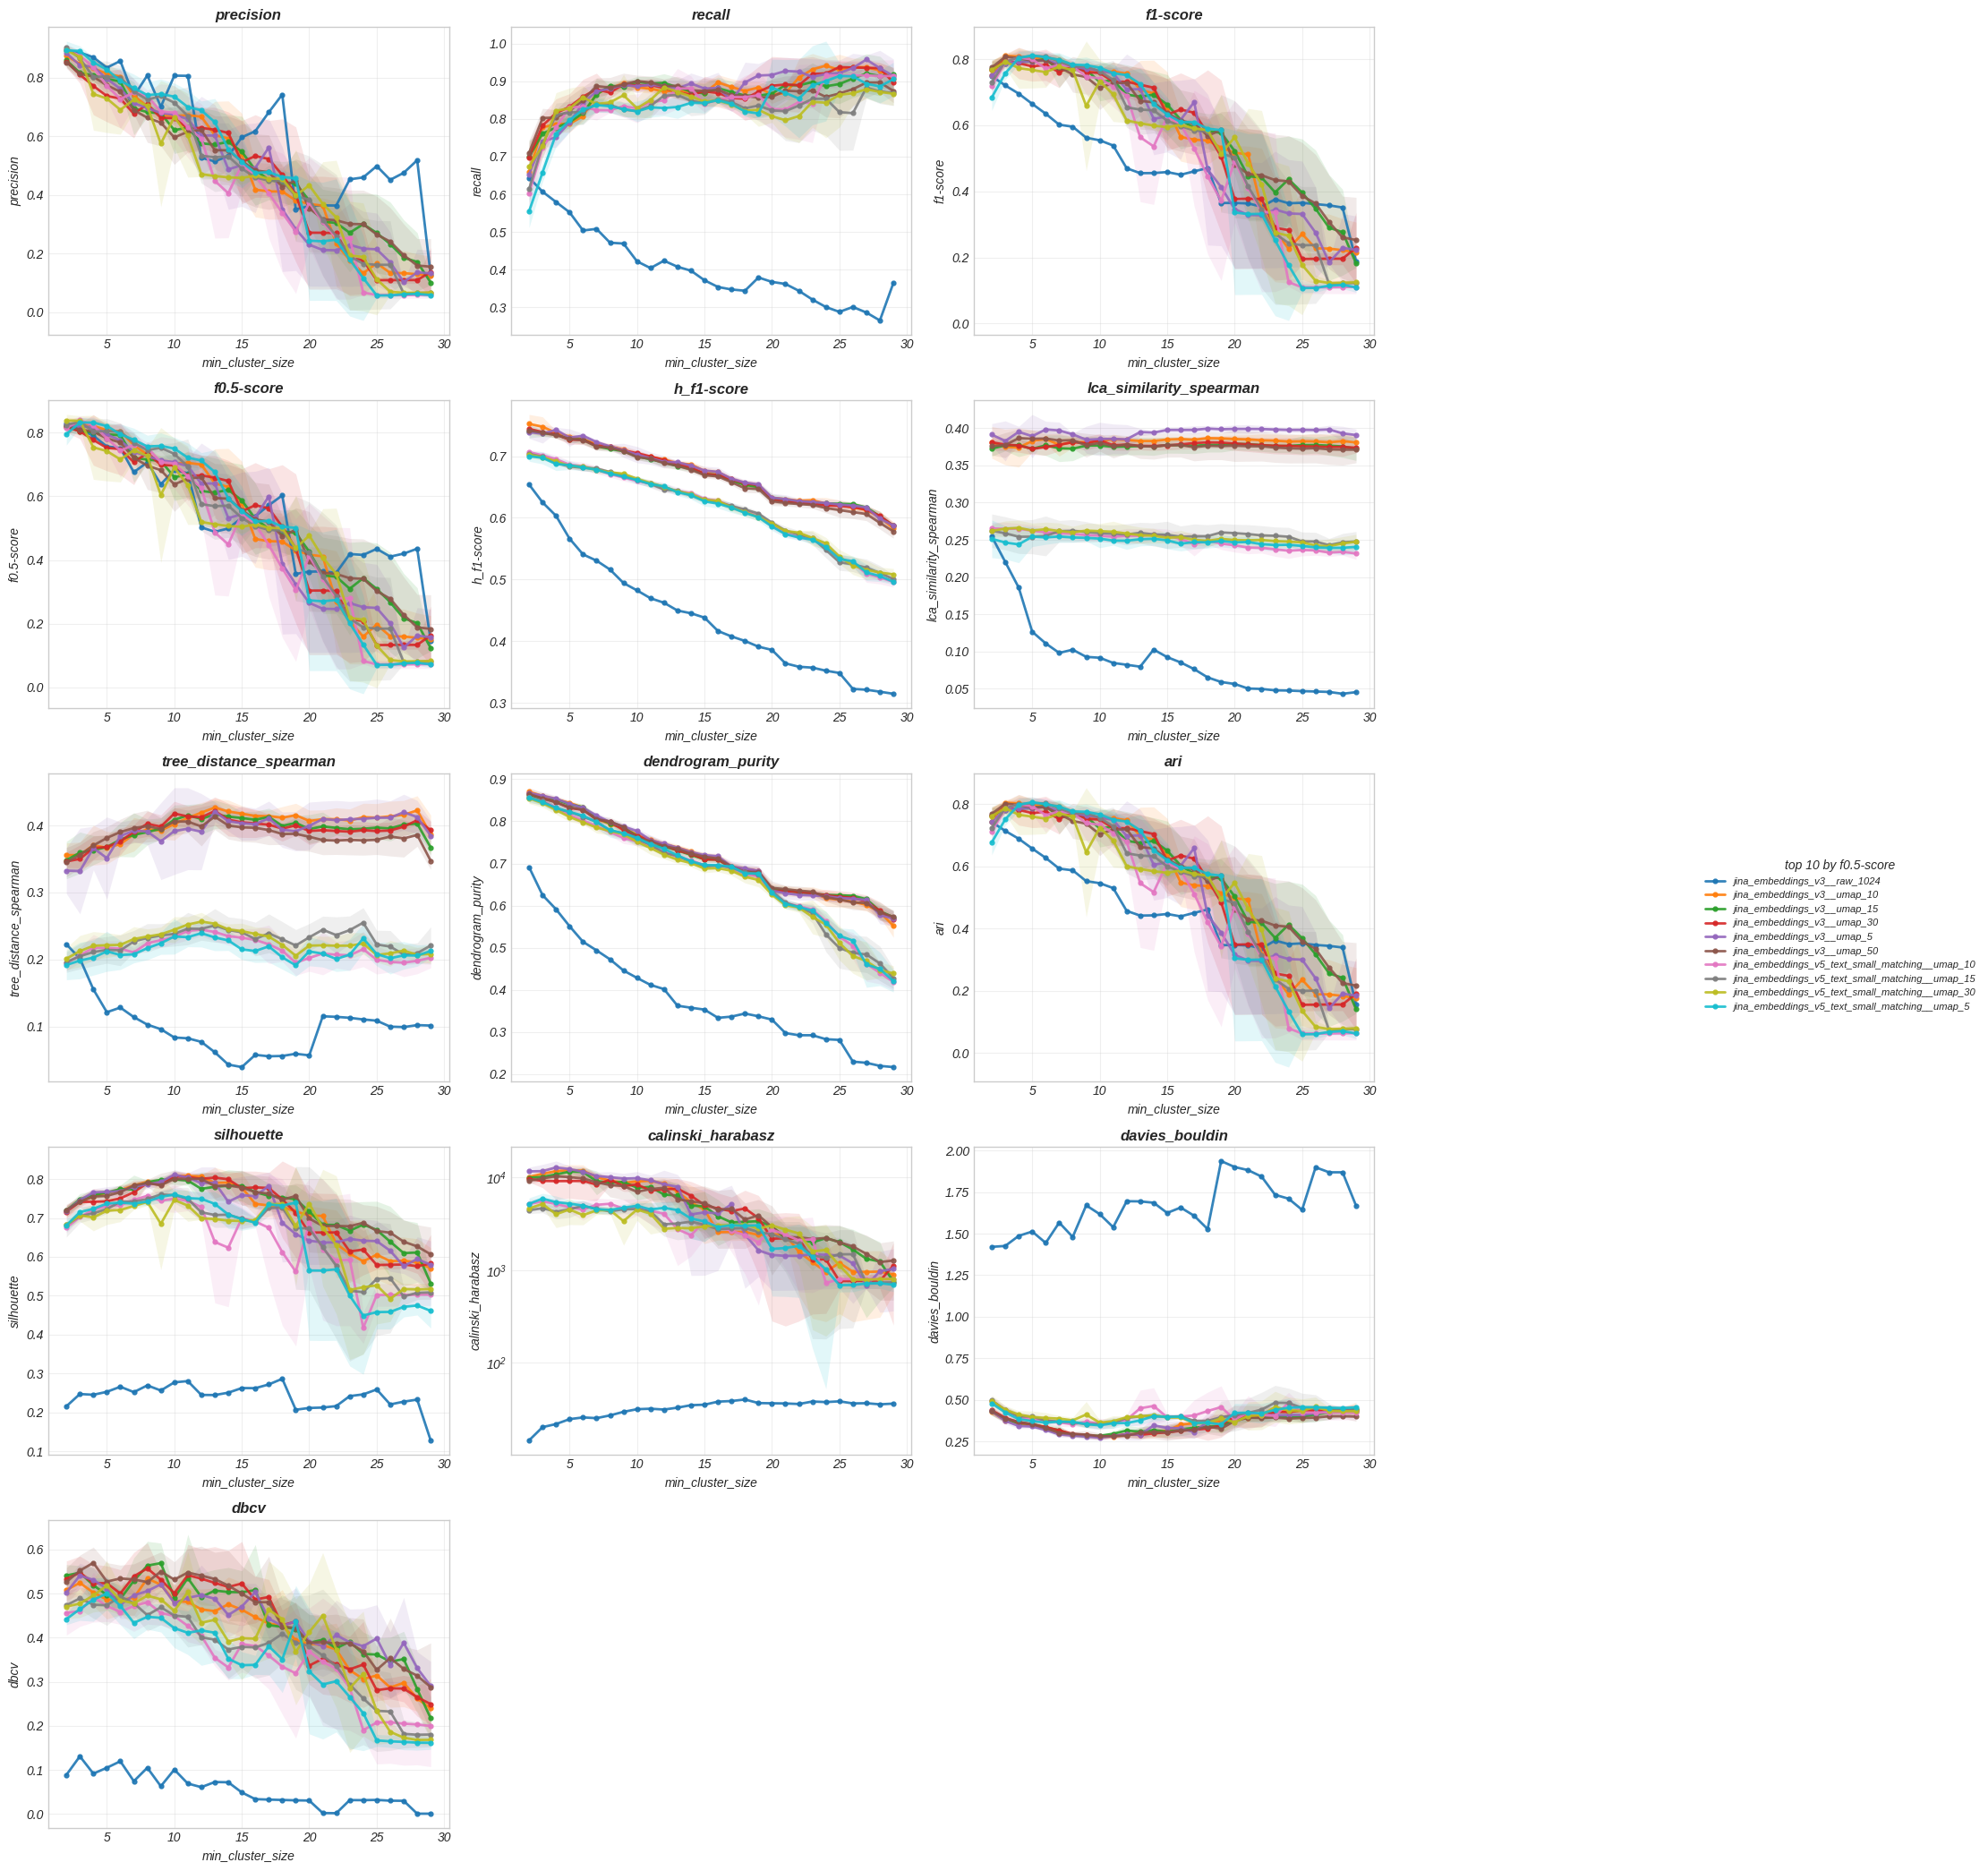

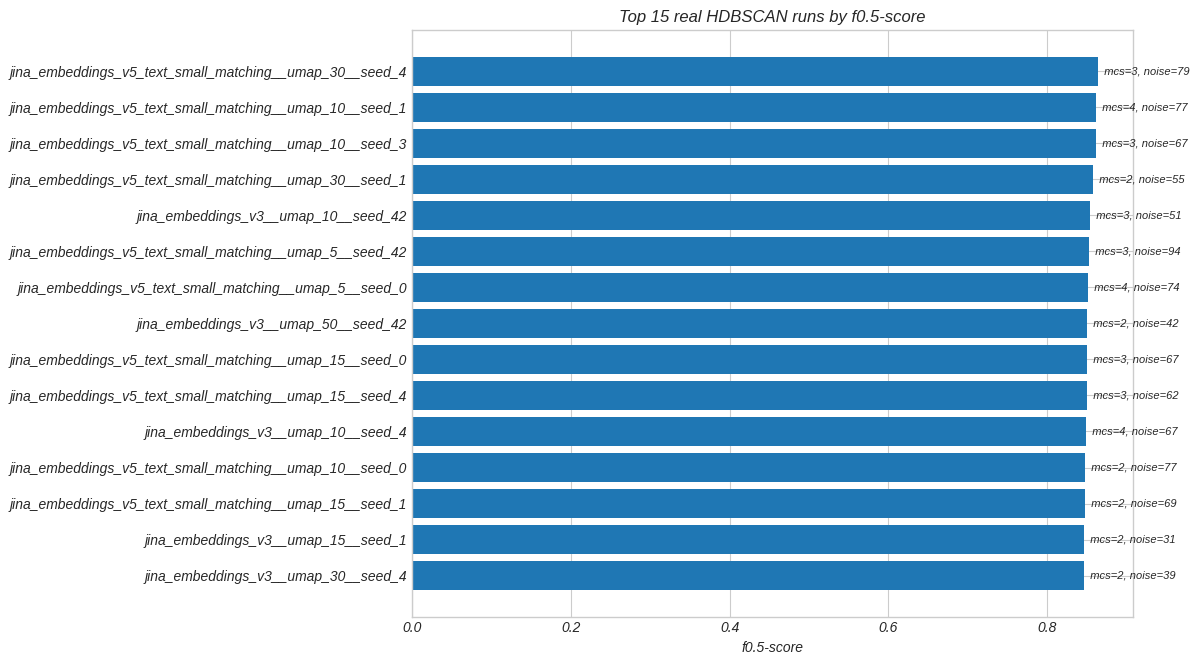

,space_id,min_cluster_size,f0.5-score,precision,recall,f1-score,h_f1-score,n_noise,n_pred_clusters
147,jina_embeddings_v5_text_small_matching__umap_3...,3,0.864747,0.892719,0.768434,0.825927,0.702219,79,55
225,jina_embeddings_v5_text_small_matching__umap_1...,4,0.862177,0.879469,0.799316,0.837479,0.700079,77,47
134,jina_embeddings_v5_text_small_matching__umap_1...,3,0.861936,0.906638,0.719948,0.802579,0.695611,67,59
51,jina_embeddings_v5_text_small_matching__umap_3...,2,0.858400,0.907049,0.706770,0.794482,0.698592,55,71
167,jina_embeddings_v3__umap_10__seed_42,3,0.854336,0.873213,0.786339,0.827502,0.735060,51,53
130,jina_embeddings_v5_text_small_matching__umap_5...,3,0.853026,0.908824,0.684841,0.781092,0.713363,94,57
218,jina_embeddings_v5_text_small_matching__umap_5...,4,0.851203,0.873014,0.773866,0.820455,0.690180,74,51
92,jina_embeddings_v3__umap_50__seed_42,2,0.850485,0.891834,0.717433,0.795183,0.742556,42,75
137,jina_embeddings_v5_text_small_matching__umap_1...,3,0.850210,0.892902,0.713711,0.793314,0.695114,67,59
141,jina_embeddings_v5_text_small_matching__umap_1...,3,0.849810,0.895220,0.706468,0.789722,0.699313,62,59


In [34]:
plot_hdbscan_results(
    "results_hdbscan_top_by_f05",
    metric_for_top="f0.5-score",
    top_n=10,
    aggregate_umap_seeds=True,
    show_std=True,
)

best_hdbscan_by_f05 = plot_hdbscan_best_summary(metric="f0.5-score", top_n=15)

In [35]:
def build_single_space_from_result_row(row, embeddings_dict, pca_dim=100):
    emb_name = row["embeddings"]
    reduction = row["reduction"]
    reduction_dim = int(row["reduction_dim"])
    X_raw = embeddings_dict[emb_name]

    if reduction == "raw":
        return normalize(X_raw)

    if reduction != "umap":
        raise ValueError(f"Unsupported reduction: {reduction}")

    use_pca = False if "jina_embeddings" in emb_name else True
    umap_seed = int(row.get("umap_seed", 42))

    return reduce_embeddings(
        X_raw,
        pca_dim=pca_dim,
        umap_dim=reduction_dim,
        return_twonn=False,
        use_pca=use_pca,
        umap_seed=umap_seed,
    )


def cluster_label_summary(y_true, y_pred, top_k=5):
    rows = []
    for cluster_id in sorted(label for label in set(y_pred) if label != -1):
        mask = y_pred == cluster_id
        labels = pd.Series(y_true[mask]).value_counts()
        size = int(mask.sum())
        dominant_label = labels.index[0]
        dominant_count = int(labels.iloc[0])

        rows.append({
            "cluster_id": cluster_id,
            "size": size,
            "dominant_label": dominant_label,
            "purity": dominant_count / size if size else np.nan,
            "top_labels": "; ".join(f"{idx}: {value}" for idx, value in labels.head(top_k).items()),
        })

    return pd.DataFrame(rows).sort_values(["purity", "size"], ascending=[True, False])


def plot_partition_from_result_row(
    row,
    embeddings_dict,
    y_true,
    title=None,
    annotate_top_clusters=12,
    random_state=42,
):
    X_space = build_single_space_from_result_row(row, embeddings_dict)
    min_cluster_size = int(row["min_cluster_size"])
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
    ).fit(X_space)
    y_pred = clusterer.labels_

    if X_space.shape[1] == 2:
        X_plot = X_space
    else:
        X_plot = UMAP(
            n_components=2,
            metric="cosine",
            random_state=random_state,
        ).fit_transform(X_space)

    summary = cluster_label_summary(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 7))
    noise_mask = y_pred == -1
    ax.scatter(
        X_plot[noise_mask, 0],
        X_plot[noise_mask, 1],
        c="lightgray",
        s=18,
        alpha=0.55,
        label="noise",
    )

    cluster_ids = sorted(label for label in set(y_pred) if label != -1)
    cmap = plt.get_cmap("tab20")

    for idx, cluster_id in enumerate(cluster_ids):
        mask = y_pred == cluster_id
        ax.scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            s=24,
            alpha=0.8,
            color=cmap(idx % cmap.N),
        )

    for _, cluster_info in summary.sort_values("size", ascending=False).head(annotate_top_clusters).iterrows():
        cluster_id = cluster_info["cluster_id"]
        mask = y_pred == cluster_id
        centroid = X_plot[mask].mean(axis=0)
        ax.text(
            centroid[0],
            centroid[1],
            f"{cluster_id}: {cluster_info['dominant_label']}\n"
            f"p={cluster_info['purity']:.2f}, n={cluster_info['size']}",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.75},
        )

    if title is None:
        title = (
            f"{row.get('selection_criterion', 'selected')} | {row['space_id']} | "
            f"min_cluster_size={min_cluster_size}"
        )

    ax.set_title(title)
    ax.set_xlabel("projection dim 1")
    ax.set_ylabel("projection dim 2")
    ax.legend(loc="best")
    plt.show()

    display(summary.head(20).round(4))
    return clusterer, summary


def plot_best_partitions(
    space_level_df,
    embeddings_dict,
    y_true,
    criteria=("best_by_f1", "best_by_f0.5", "best_by_h_f1", "best_by_calinski_harabasz"),
    metric_by_criterion=None,
):
    if metric_by_criterion is None:
        metric_by_criterion = {
            "best_by_f1": "f1-score",
            "best_by_f0.5": "f0.5-score",
            "best_by_h_f1": "h_f1-score",
            "best_by_calinski_harabasz": "calinski_harabasz",
            "best_by_silhouette": "silhouette",
            "best_by_davies_bouldin": "davies_bouldin",
        }

    for criterion in criteria:
        part = space_level_df[space_level_df["selection_criterion"] == criterion]
        if part.empty:
            continue

        metric = metric_by_criterion[criterion]
        if criterion == "best_by_davies_bouldin":
            row = part.loc[part[metric].idxmin()]
        else:
            row = part.loc[part[metric].idxmax()]

        print(f"\nVisual inspection for {criterion}")
        display(row.to_frame("value"))
        plot_partition_from_result_row(
            row,
            embeddings_dict=embeddings_dict,
            y_true=y_true,
            title=f"{criterion}: {row['space_id']}",
        )



Visual inspection for best_by_f1


,value
selection_criterion,best_by_f1
selection_metric,f1-score
selection_direction,max
algorithm,hdbscan
space_id,jina_embeddings_v5_text_small_matching__umap_1...
embeddings,jina_embeddings_v5_text_small_matching
reduction,umap
reduction_dim,10
umap_seed,1
precision,0.879469


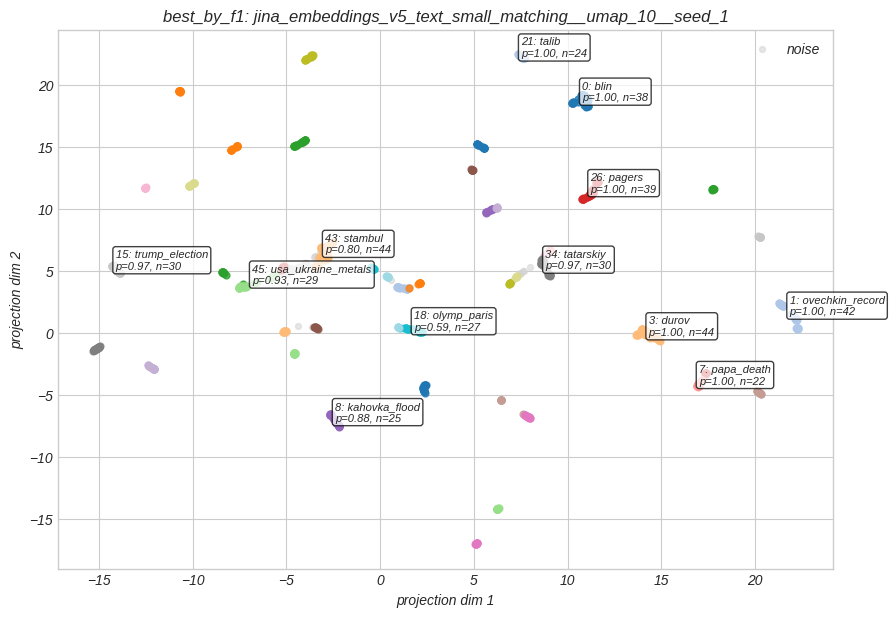

,cluster_id,size,dominant_label,purity,top_labels
11,11,10,neuralink,0.5000,neuralink: 5; starship: 5
33,33,6,shoot_makhachkala,0.5000,shoot_makhachkala: 3; explode_tulen: 2; novoru...
30,30,9,9may_politics,0.5556,9may_politics: 5; vuchich_ill: 4
13,13,7,merz_election,0.5714,merz_election: 4; adg_extreme: 3
18,18,27,olymp_paris,0.5926,olymp_paris: 16; olymp_paris_collapse: 10; 9ma...
46,46,5,russia_ukraine_negotiations,0.6000,russia_ukraine_negotiations: 3; oil_fall: 1; s...
23,23,11,misha_ill,0.6364,misha_ill: 7; medinskiy_writer_union: 3; strai...
22,22,17,pridnestr_gaz,0.6471,pridnestr_gaz: 11; pridnestr: 6
44,44,11,usa_russia_metals,0.7273,usa_russia_metals: 8; usa_ukraine_metals: 3
43,43,44,stambul,0.7955,stambul: 35; russia_ukraine_negotiations: 3; d...



Visual inspection for best_by_f0.5


,value
selection_criterion,best_by_f0.5
selection_metric,f0.5-score
selection_direction,max
algorithm,hdbscan
space_id,jina_embeddings_v5_text_small_matching__umap_3...
embeddings,jina_embeddings_v5_text_small_matching
reduction,umap
reduction_dim,30
umap_seed,4
precision,0.892719


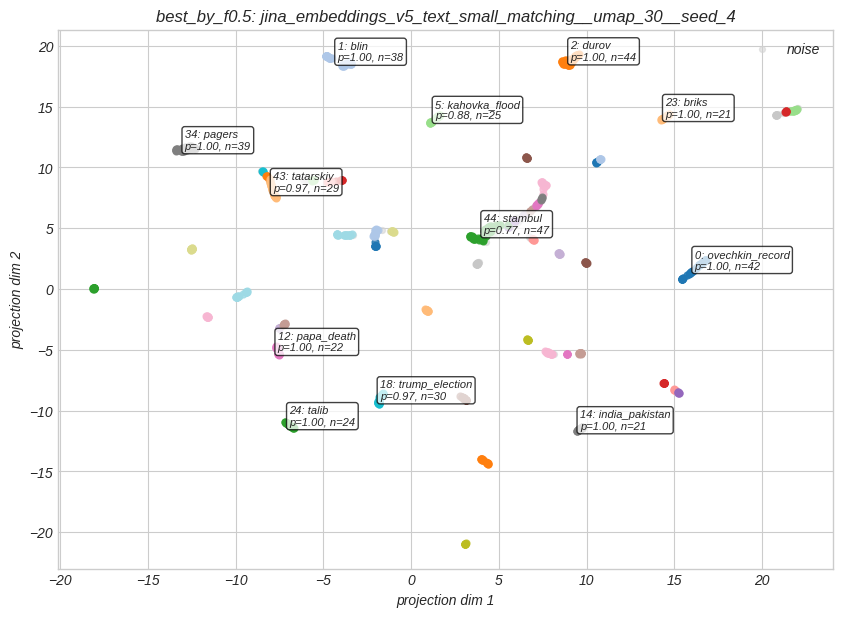

,cluster_id,size,dominant_label,purity,top_labels
49,49,5,russia_ukraine_negotiations,0.4000,russia_ukraine_negotiations: 2; trump_election...
48,48,4,nancy_visit,0.5000,nancy_visit: 2; trump_election: 1; stambul: 1
35,35,9,9may_politics,0.5556,9may_politics: 5; vuchich_ill: 4
16,16,7,merz_election,0.5714,merz_election: 4; adg_extreme: 3
42,42,5,shoot_makhachkala,0.6000,shoot_makhachkala: 3; explode_tulen: 1; tatars...
22,22,17,pridnestr_gaz,0.6471,pridnestr_gaz: 11; pridnestr: 6
25,25,13,olymp_paris_collapse,0.6923,olymp_paris_collapse: 9; olymp_paris: 3; 9may_...
44,44,47,stambul,0.7660,stambul: 36; russia_ukraine_negotiations: 3; d...
40,40,9,rebellion,0.7778,rebellion: 7; vagner_spb: 2
9,9,5,conclave,0.8000,conclave: 4; papa_death: 1



Visual inspection for best_by_h_f1


,value
selection_criterion,best_by_h_f1
selection_metric,h_f1-score
selection_direction,max
algorithm,hdbscan
space_id,jina_embeddings_v3__umap_10__seed_3
embeddings,jina_embeddings_v3
reduction,umap
reduction_dim,10
umap_seed,3
precision,0.877572


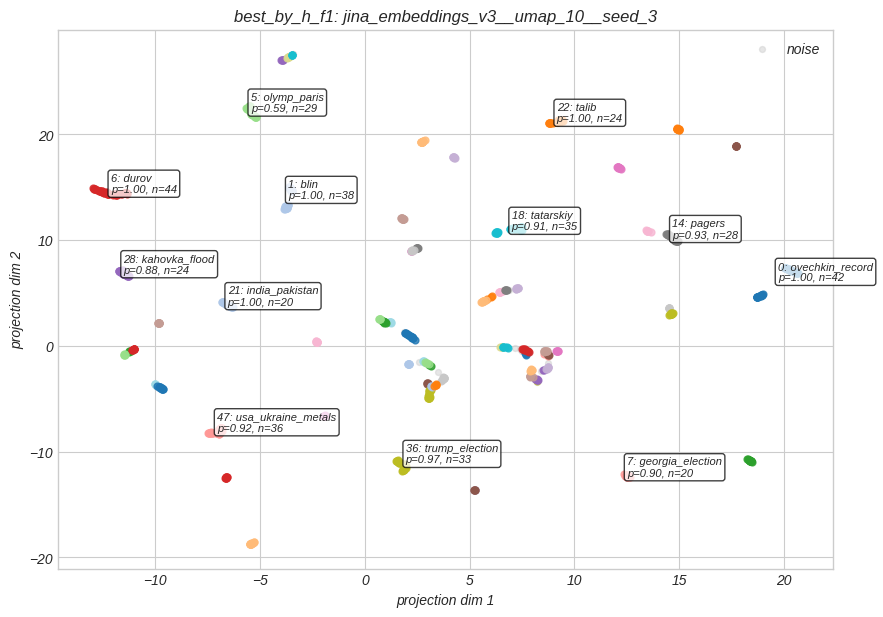

,cluster_id,size,dominant_label,purity,top_labels
27,27,3,novorussia_bpla,0.3333,novorussia_bpla: 1; straight_line: 1; kahovka_...
60,60,6,donbass_kiev,0.5000,donbass_kiev: 3; kiev_visit: 2; stambul: 1
68,68,2,oil_fall,0.5000,oil_fall: 1; stambul: 1
63,63,7,russia_ukraine_negotiations,0.5714,russia_ukraine_negotiations: 4; stambul: 2; us...
40,40,19,straight_line,0.5789,straight_line: 11; straight_line_after: 4; 9ma...
5,5,29,olymp_paris,0.5862,olymp_paris: 17; olymp_paris_collapse: 10; 9ma...
43,43,10,9may_politics,0.6000,9may_politics: 6; vuchich_ill: 4
4,4,18,pridnestr_gaz,0.6111,pridnestr_gaz: 11; pridnestr: 7
51,51,6,russia_ukraine_negotiations,0.6667,russia_ukraine_negotiations: 4; usa_ukraine_me...
30,30,4,adg_extreme,0.7500,adg_extreme: 3; 9may_politics: 1



Visual inspection for best_by_calinski_harabasz


,value
selection_criterion,best_by_calinski_harabasz
selection_metric,calinski_harabasz
selection_direction,max
algorithm,hdbscan
space_id,jina_embeddings_v3__umap_5__seed_4
embeddings,jina_embeddings_v3
reduction,umap
reduction_dim,5
umap_seed,4
precision,0.8471


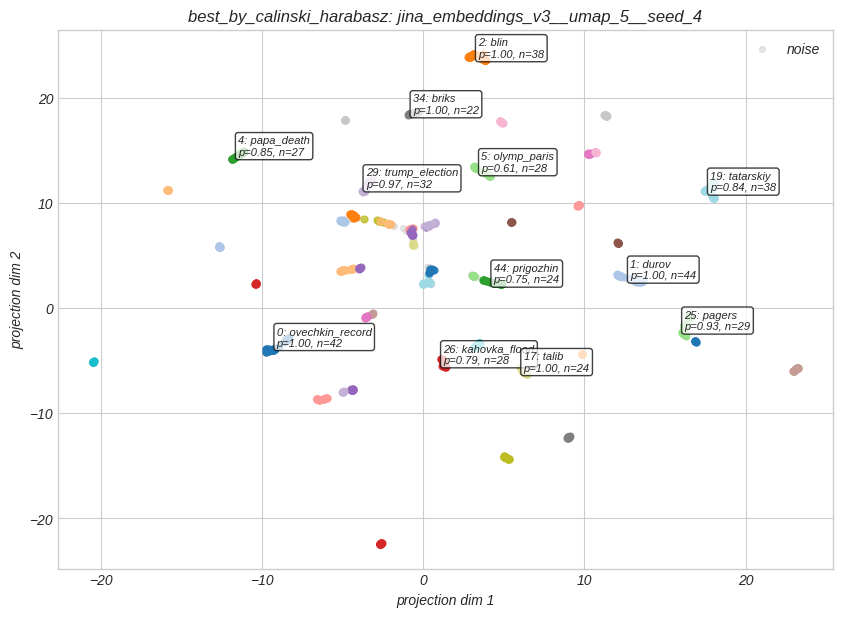

,cluster_id,size,dominant_label,purity,top_labels
7,7,19,deepseek,0.4737,deepseek: 9; neuralink: 5; team_spirit: 4; nan...
28,28,8,merz_election,0.5000,merz_election: 4; adg_extreme: 3; 9may_politic...
43,43,8,russia_ukraine_negotiations,0.5000,russia_ukraine_negotiations: 4; stambul: 2; us...
36,36,7,russia_ukraine_negotiations,0.5714,russia_ukraine_negotiations: 4; usa_ukraine_me...
5,5,28,olymp_paris,0.6071,olymp_paris: 17; olymp_paris_collapse: 10; kie...
11,11,18,pridnestr_gaz,0.6111,pridnestr_gaz: 11; pridnestr: 7
33,33,12,9may_politics,0.6667,9may_politics: 8; vuchich_ill: 4
48,48,12,stambul,0.6667,stambul: 8; russia_ukraine_negotiations: 3; do...
44,44,24,prigozhin,0.7500,prigozhin: 18; rebellion: 6
39,39,16,straight_line,0.7500,straight_line: 12; straight_line_after: 4


In [36]:
plot_best_partitions(space_level_df, embeddings_dict, y_true)

In [37]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"
external_metrics_for_space_corr = globals().get("external_metrics_reduced", external_metrics)

for group_name, part in hdbscan_df.groupby(group_col):
    corr = spearman_corr_table(
        part,
        internal_metrics_for_corr,
        external_metrics_for_space_corr,
    )
    print(group_name)
    display(corr.round(6))

jina_embeddings_v3__raw_1024


,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.642036,0.178982,0.539135,0.617953,0.268747,0.408320,0.412698,0.412698,0.397373
calinski_harabasz,-0.661741,-0.868637,-0.699507,-0.690203,-0.290640,-0.802956,-0.804050,-0.756431,-0.803503
davies_bouldin_inv,0.900383,0.665572,0.849480,0.891078,0.555556,0.767378,0.762452,0.757526,0.752600
dbcv,0.863164,0.840722,0.927203,0.883963,0.564313,0.925014,0.924466,0.906404,0.915161


jina_embeddings_v3__umap_10__seed_0


,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.761357,-0.301587,0.783251,0.763547,0.759168,0.741653,0.742748,0.661741,0.741653
calinski_harabasz,0.961138,-0.695129,0.963875,0.960591,0.904762,0.910783,0.914614,0.402846,0.910783
davies_bouldin_inv,0.635468,-0.185003,0.685276,0.637110,0.638752,0.633826,0.632184,0.571976,0.633826
dbcv,0.812808,-0.349754,0.787630,0.817187,0.847291,0.862616,0.864806,0.528188,0.862616


jina_embeddings_v3__umap_10__seed_1


...

,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.675424,0.020799,0.813355,0.759715,0.738369,0.667761,0.669403,0.348659,0.668309
calinski_harabasz,0.972633,-0.434045,0.798030,0.890531,0.679803,0.834154,0.835796,0.263273,0.833060
davies_bouldin_inv,0.729611,-0.354132,0.723591,0.788725,0.697865,0.616858,0.619048,0.089217,0.617953
dbcv,0.241379,-0.450465,0.151067,0.168582,0.074439,0.313629,0.314724,-0.048714,0.308155


tfidf_svd__umap_5__seed_4


,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.255063,-0.338259,0.515599,0.365627,-0.259442,0.088670,0.095238,-0.217843,0.092501
calinski_harabasz,0.979201,-0.643678,0.625068,0.913519,0.701697,0.895457,0.898194,0.341544,0.900930
davies_bouldin_inv,0.588396,-0.371648,0.759168,0.738369,0.144499,0.468528,0.472906,-0.011494,0.469622
dbcv,0.530925,-0.610290,0.440613,0.530925,0.011494,0.542967,0.525999,0.165846,0.544061


tfidf_svd__umap_5__seed_42


,precision,recall,f1-score,f0.5-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,dendrogram_purity
silhouette,0.274767,0.418777,0.636563,0.386426,-0.002189,0.128626,0.128626,0.070060,0.127531
calinski_harabasz,0.981938,-0.069249,0.586207,0.900930,0.838533,0.903667,0.903667,0.758621,0.900930
davies_bouldin_inv,0.740558,0.330368,0.834154,0.887794,0.634373,0.687466,0.687466,0.639847,0.684729
dbcv,0.494253,0.328726,0.541872,0.542967,0.565955,0.597701,0.597701,0.603722,0.594964


In [38]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"

for group_name, part in hdbscan_df.groupby(group_col):
    best_by_f1 = part.loc[part["f1-score"].idxmax()]
    best_by_f05 = part.loc[part["f0.5-score"].idxmax()] if "f0.5-score" in part.columns else None
    best_by_hf1 = part.loc[part["h_f1-score"].idxmax()]
    best_by_ch = part.loc[part["calinski_harabasz"].idxmax()]
    best_by_sil = part.loc[part["silhouette"].idxmax()]
    best_by_db = part.loc[part["davies_bouldin"].idxmin()]
    best_by_dbcv = part.loc[part["dbcv"].idxmax()]

    print("\n", group_name)
    print("Best by F1:", best_by_f1["min_cluster_size"], " | ", best_by_f1["f1-score"])
    if best_by_f05 is not None:
        print(
            "Best by F0.5:", best_by_f05["min_cluster_size"],
            " | ", best_by_f05["f0.5-score"],
            "precision:", best_by_f05["precision"],
            "recall:", best_by_f05["recall"],
        )
    print("Best by hF1:", best_by_hf1["min_cluster_size"], " | ", best_by_hf1["h_f1-score"])
    print("=" * 50)
    print("Selected by CH:", best_by_ch["min_cluster_size"], " | ", best_by_ch["f1-score"], best_by_ch["h_f1-score"])
    print("Selected by silhouette:", best_by_sil["min_cluster_size"], " | ", best_by_sil["f1-score"], best_by_sil["h_f1-score"])
    print("Selected by DB:", best_by_db["min_cluster_size"], " | ", best_by_db["f1-score"], best_by_db["h_f1-score"])
    print("Selected by dbcv:", best_by_dbcv["min_cluster_size"], " | ", best_by_dbcv["f1-score"], best_by_dbcv["h_f1-score"])


 jina_embeddings_v3__raw_1024
Best by F1: 2  |  0.7485236508214933
Best by F0.5: 2  |  0.8293814299411749 precision: 0.8937447640323932 recall: 0.6438990041243335
Best by hF1: 2  |  0.654131126213358
Selected by CH: 18  |  0.47051546391752574 0.40046860182009153
Selected by silhouette: 18  |  0.47051546391752574 0.40046860182009153
Selected by DB: 2  |  0.7485236508214933 0.654131126213358
Selected by dbcv: 3  |  0.7205636493909721 0.6250538027846387

 jina_embeddings_v3__umap_10__seed_0
Best by F1: 6  |  0.8146637434354764
Best by F0.5: 2  |  0.8379078073686985 precision: 0.8800352467270897 recall: 0.7032491701036113
Best by hF1: 2  |  0.7434771841865615
Selected by CH: 6  |  0.8146637434354764 0.7241491156377153
Selected by silhouette: 12  |  0.7678445229681979 0.694162586626741
Selected by DB: 11  |  0.7670437307675639 0.7012256053318986
Selected by dbcv: 3  |  0.8012415712297978 0.7383743845543346

 jina_embeddings_v3__umap_10__seed_1
Best by F1: 4  |  0.8099915504858471
Best by F